## Fama French Five Factor Benchmark


### 1. Setup

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.size'] = 12

### 2. Configuration

In [2]:
country = 'USA'
raw_path = Path(f'../data/Global Factor_{country}.parquet')
results_dir = Path('../results') / country / 'ff_benchmark'
results_dir.mkdir(parents = True, exist_ok = True)

# JKP characteristic names for FF5 factors
char_map = {
	'size': 'me',
	'value': 'be_me',
	'profitability': 'ope_be',
	'investment': 'at_gr1',
	'momentum': 'ret_12_1',
}

# For FM regression, use a broader set of characteristics
fm_chars = ['be_me', 'ret_12_1', 'ope_be', 'at_gr1', 'market_equity',
	'gp_at', 'ni_be', 'ebit_sale', 'debt_at', 'rvol_21d',
	'beta_60m', 'ret_1_0', 'ret_6_1', 'ocf_at', 'noa_at']

rebalance_freq = 6
tc_bps = 25
min_stocks = 30
ret_clip_low = -1
ret_clip_high = 1

id_cols = ['id', 'gvkey', 'eom', 'excntry', 'ret_exc_lead1m', 'me']

print(f'country: {country}')

country: USA


### 3. Load and Process

In [3]:
schema = pq.read_schema(raw_path)
all_col_names = schema.names

# Gather all needed columns
factor_cols = list(set(char_map.values()))
fm_available = [c for c in fm_chars if c in all_col_names]
all_chars = list(set(factor_cols + fm_available))
needed = [c for c in id_cols + all_chars if c in all_col_names]
needed = list(dict.fromkeys(needed))  # Remove duplicates preserving order

df = pd.read_parquet(raw_path, columns = needed)
df['eom'] = pd.to_datetime(df['eom'])
print(f'loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'date range: {df["eom"].min().date()} to {df["eom"].max().date()}')

# Downcast
for col in all_chars:
	if col in df.columns and df[col].dtype == np.float64:
		df[col] = df[col].astype(np.float32)
if 'me' in df.columns and df['me'].dtype == np.float64:
	df['me'] = df['me'].astype(np.float32)

# Winsorise returns
ret_col = 'ret_exc_lead1m'
raw_count = df[ret_col].notna().sum()
df[ret_col] = df[ret_col].clip(lower = ret_clip_low, upper = ret_clip_high)
print(f'returns clipped to [{ret_clip_low}, {ret_clip_high}]')

# Firm lookup
info_cols = [c for c in ['id', 'gvkey', 'excntry'] if c in df.columns]
firm_lookup = df[info_cols].drop_duplicates(subset = ['id'])
id_to_gvkey = dict(zip(firm_lookup['id'], firm_lookup.get('gvkey', firm_lookup['id'])))


loaded: 2,075,188 rows, 21 columns
date range: 1995-01-31 to 2025-12-31
returns clipped to [-1, 1]


### 4. Build Monthly Cross Sections

In [4]:
sorted_eoms = sorted(df['eom'].unique())
all_months = {}

for eom in sorted_eoms:
	month = df[df['eom'] == eom].copy()
	has_ret = month[ret_col].notna()
	month = month[has_ret]
	if len(month) < min_stocks: continue

	entry = {
		'ids': month['id'].values,
		'r': month[ret_col].values.astype(np.float64),
		'me': month['me'].values.astype(np.float64) if 'me' in month.columns else np.ones(len(month)),
	}
	# Factor characteristics (raw, not normalised)
	for fname, cname in char_map.items():
		if cname in month.columns:
			entry[fname] = month[cname].values.astype(np.float64)
		else:
			entry[fname] = np.full(len(month), np.nan)
	# FM characteristics (rank normalised for regression)
	fm_vals = {}
	for cname in fm_available:
		if cname in month.columns:
			vals = month[cname].values.astype(np.float64)
			# Rank normalise to [-0.5, 0.5]
			valid = np.isfinite(vals)
			if valid.sum() > 5:
				ranked = np.full_like(vals, 0.0)
				temp = pd.Series(vals[valid]).rank(pct = True).values - 0.5
				ranked[valid] = temp
				fm_vals[cname] = ranked
			else:
				fm_vals[cname] = np.zeros(len(month))
		else:
			fm_vals[cname] = np.zeros(len(month))
	entry['fm_X'] = np.column_stack([fm_vals[c] for c in fm_available])
	all_months[eom] = entry

sorted_dates = sorted(all_months.keys())
print(f'processed: {len(sorted_dates)} months')
print(f'~{np.mean([len(m["ids"]) for m in all_months.values()]):.0f} firms/month')

processed: 371 months
~5415 firms/month


### 5. Market Portfolio

In [5]:
market_rets = []
market_dates = []

for eom in sorted_dates:
	m = all_months[eom]
	me = m['me']
	r = m['r']
	valid = np.isfinite(me) & (me > 0) & np.isfinite(r)
	if valid.sum() < 5: continue
	weights = me[valid] / me[valid].sum()
	market_rets.append(float((weights * r[valid]).sum()))
	market_dates.append(eom)

market_rets = np.array(market_rets)
mkt_sharpe = market_rets.mean() / max(market_rets.std(), 1e-8) * np.sqrt(12)
mkt_ann_ret = float((1 + market_rets).prod() ** (12 / len(market_rets)) - 1)
print(f'market: {len(market_rets)} months, sharpe: {mkt_sharpe:.4f}, ann ret: {mkt_ann_ret * 100:.2f}%')

market: 371 months, sharpe: 0.5844, ann ret: 8.26%


### 6. Quintile Factor Portfolios

Equal weighted quintile long short portfolios for each factor. Six month rebalancing with transaction costs.

In [6]:
def portfolio_metrics(rets):
	if len(rets) == 0: return {}
	tw = float((1 + rets).prod())
	ann_ret = -1.0 if tw <= 0 else float(tw ** (12 / len(rets)) - 1)
	ann_vol = float(rets.std() * np.sqrt(12))
	sharpe = ann_ret / max(ann_vol, 1e-8)
	se = float(np.sqrt((1 + 0.5 * sharpe ** 2) / len(rets)))
	pk = np.maximum.accumulate(np.cumprod(1 + rets))
	max_dd = float(((pk - np.cumprod(1 + rets)) / pk).max()) if len(pk) > 0 else 0
	return {'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe, 'se_sharpe': se, 'max_dd': max_dd, 'n_months': len(rets)}


def quintile_factor(factor_name, reverse = False):
	"""Quintile long short for one factor. reverse = True means low values are long."""
	keys = sorted_dates
	rset = set(keys[::rebalance_freq])
	ml = []
	li = set()
	si = set()
	pl = set()
	ps = set()
	hl = []

	for eom in keys:
		m = all_months[eom]
		ids = m['ids']
		r = m['r']
		char_vals = m.get(factor_name)
		if char_vals is None: continue

		tcv = 0.0
		if eom in rset:
			valid = np.isfinite(char_vals)
			if valid.sum() < 10: continue
			vi = ids[valid]
			vc = char_vals[valid]
			nq = max(1, int(len(vi) * 0.20))
			so = np.argsort(vc)

			if reverse:
				li = set(vi[so[:nq]].tolist())
				si = set(vi[so[::-1][:nq]].tolist())
			else:
				li = set(vi[so[::-1][:nq]].tolist())
				si = set(vi[so[:nq]].tolist())

			to = (len(li - pl) + len(pl - li) + len(si - ps) + len(ps - si)) / max(nq, 1)
			tcv = to * tc_bps / 10000.0
			pl = li
			ps = si
			hl.append({'eom': str(eom), 'n_long': len(li), 'n_short': len(si),
				'long': sorted(li), 'short': sorted(si)})

		if not li: continue
		il = ids.tolist()
		lr = r[np.array([i in li for i in il])]
		sr = r[np.array([i in si for i in il])]
		ml.append((float(lr.mean()) if len(lr) > 0 else 0) - (float(sr.mean()) if len(sr) > 0 else 0) - tcv)

	return np.array(ml), hl


# Factor definitions: (name, reverse)
factor_defs = [
	('value', False),
	('momentum', False),
	('profitability', False),
	('investment', True),
	('size', True),
]

factor_results = {}
print(f'Quintile Factor Portfolios ({country})')
print()
for fname, rev in factor_defs:
	rets, holdings = quintile_factor(fname, reverse = rev)
	if len(rets) == 0:
		print(f'{fname}: no data')
		continue
	m = portfolio_metrics(rets)
	factor_results[fname] = {'returns': rets, 'holdings': holdings, 'metrics': m, 'reversed': rev}
	print(f'{fname:<15} sharpe: {m["sharpe"]:7.5f} (se {m["se_sharpe"]:.5f})  '
		f'ret: {m["ann_ret"] * 100:6f}%  vol: {m["ann_vol"] * 100:5f}%  dd: {m["max_dd"] * 100:5f}%')

Quintile Factor Portfolios (USA)

value           sharpe: 0.12110 (se 0.05211)  ret: 1.859620%  vol: 15.355875%  dd: 55.936461%
momentum        sharpe: 0.68561 (se 0.05770)  ret: 13.128864%  vol: 19.149080%  dd: 58.900292%
profitability   sharpe: 0.69663 (se 0.05787)  ret: 14.624814%  vol: 20.993637%  dd: 65.024608%
investment      sharpe: 0.39381 (se 0.05389)  ret: 4.577748%  vol: 11.624354%  dd: 46.886220%
size            sharpe: -0.62523 (se 0.05676)  ret: -11.004981%  vol: 17.601437%  dd: 97.639115%


### 7. Fama MacBeth Cross Sectional Regression

Each month, regress excess returns on rank normalised characteristics. The time series average of the monthly slope coefficients gives the risk premium estimate. The t statistic tests whether each characteristic commands a significant premium.

In [7]:
# Run monthly cross-sectional regressions
fm_betas = []
fm_dates = []

for eom in sorted_dates:
	m = all_months[eom]
	X = m['fm_X']
	r = m['r']

	# Drop rows with NaN in X or r
	valid = np.isfinite(r)
	for j in range(X.shape[1]):
		valid = valid & np.isfinite(X[:, j])
	if valid.sum() < len(fm_available) + 5: continue

	X_v = X[valid]
	r_v = r[valid]

	# Add intercept
	X_aug = np.column_stack([np.ones(len(X_v)), X_v])

	try:
		beta = np.linalg.lstsq(X_aug, r_v, rcond = None)[0]
		fm_betas.append(beta)
		fm_dates.append(eom)
	except np.linalg.LinAlgError:
		continue

fm_betas = np.array(fm_betas)
n_months_fm = len(fm_betas)

# Fama-MacBeth statistics
fm_mean = fm_betas.mean(axis = 0)
fm_se = fm_betas.std(axis = 0) / np.sqrt(n_months_fm)
fm_tstat = fm_mean / np.maximum(fm_se, 1e-10)

print(f'Fama MacBeth Regression ({n_months_fm} months, {len(fm_available)} characteristics)')
print(f'{"Variable":<20} {"Mean Coef":>10} {"SE":>10} {"t stat":>10} {"p value":>10}')

coef_names = ['intercept'] + fm_available
fm_results_table = []
for i, name in enumerate(coef_names):
	p_val = 2 * (1 - stats.t.cdf(abs(fm_tstat[i]), df = n_months_fm - 1))
	sig = '***' if p_val < 0.01 else '**' if p_val < 0.05 else '*' if p_val < 0.10 else ''
	print(f'  {name:<18} {fm_mean[i]:10.5f} {fm_se[i]:10.5f} {fm_tstat[i]:10.5f} {p_val:10.5f} {sig}')
	fm_results_table.append({'variable': name, 'mean_coef': float(fm_mean[i]),
		'se': float(fm_se[i]), 't_stat': float(fm_tstat[i]), 'p_value': float(p_val)})

Fama MacBeth Regression (371 months, 15 characteristics)
Variable              Mean Coef         SE     t stat    p value
  intercept             0.00522    0.00302    1.72813    0.08480 *
  be_me                 0.01455    0.00188    7.75825    0.00000 ***
  ret_12_1              0.01339    0.00205    6.52037    0.00000 ***
  ope_be                0.00341    0.00138    2.47246    0.01387 **
  at_gr1               -0.00024    0.00119   -0.19907    0.84232 
  market_equity         0.00137    0.00286    0.47845    0.63261 
  gp_at                 0.00870    0.00165    5.27610    0.00000 ***
  ni_be                -0.00345    0.00136   -2.54287    0.01140 **
  ebit_sale             0.00188    0.00160    1.17628    0.24024 
  debt_at              -0.00541    0.00119   -4.55919    0.00001 ***
  rvol_21d             -0.01724    0.00283   -6.09778    0.00000 ***
  beta_60m              0.00341    0.00198    1.72318    0.08569 *
  ret_1_0              -0.00988    0.00225   -4.39114    0.00001 

### 8. FM Regression Predictive Portfolio

Use the Fama MacBeth regression as a predictive model. Each month, fit the regression on available data and predict next month's returns using an expanding window of coefficient estimates.

In [8]:
# Expanding window FM predictions
min_history = 60  # Need at least 60 months of betas before predicting
fm_predictions = {}

for t_idx in range(min_history, len(fm_dates)):
	# Average betas from all months up to t_idx
	beta_avg = fm_betas[:t_idx].mean(axis = 0)

	# Predict using current month's characteristics
	pred_date = fm_dates[t_idx]
	m = all_months[pred_date]
	X = m['fm_X']
	ids = m['ids']
	r = m['r']

	# Predicted return = intercept + X * beta_slopes
	pred = beta_avg[0] + X @ beta_avg[1:]

	# Handle NaN predictions
	valid = np.isfinite(pred)
	if valid.sum() < 10: continue

	fm_predictions[pred_date] = {
		'w': pred[valid].astype(np.float32),
		'ids': ids[valid],
		'r': r[valid].astype(np.float32),
	}

print(f'FM predictive portfolio: {len(fm_predictions)} OOS months')
print(f'from {min(fm_predictions.keys()).date()} to {max(fm_predictions.keys()).date()}')

FM predictive portfolio: 311 OOS months
from 2000-01-31 to 2025-11-30


In [9]:
# Evaluate FM predictive portfolio
from scipy.stats import spearmanr

# Rank correlation
fm_corrs = []
for eom, p in fm_predictions.items():
	if len(p['w']) < 10: continue
	c, _ = spearmanr(p['w'], p['r'])
	if not np.isnan(c): fm_corrs.append(c)
fm_rc = float(np.mean(fm_corrs)) if fm_corrs else 0.0
print(f'FM rank correlation: {fm_rc:.4f}')

# Quintile long-short
keys = sorted(fm_predictions.keys())
rset = set(keys[::rebalance_freq])
fm_q_rets = []
li = set()
si = set()
pl = set()
ps = set()
fm_q_holdings = []

for eom in keys:
	p = fm_predictions[eom]
	w = p['w']
	r = p['r']
	ids = p['ids']
	tcv = 0.0
	if eom in rset:
		nq = max(1, int(len(w) * 0.20))
		so = np.argsort(w)
		li = set(ids[so[::-1][:nq]].tolist())
		si = set(ids[so[:nq]].tolist())
		to = (len(li - pl) + len(pl - li) + len(si - ps) + len(ps - si)) / max(nq, 1)
		tcv = to * tc_bps / 10000.0
		pl = li
		ps = si
		fm_q_holdings.append({'eom': str(eom), 'long': sorted(li), 'short': sorted(si)})
	if not li: continue
	il = ids.tolist()
	lr = r[np.array([i in li for i in il])]
	sr = r[np.array([i in si for i in il])]
	fm_q_rets.append((float(lr.mean()) if len(lr) > 0 else 0) - (float(sr.mean()) if len(sr) > 0 else 0) - tcv)

fm_q_rets = np.array(fm_q_rets)
fm_q_m = portfolio_metrics(fm_q_rets)
print(f'FM quintile sharpe: {fm_q_m.get("sharpe", 0):.4f} (se {fm_q_m.get("se_sharpe", 0):.4f})  ret: {fm_q_m.get("ann_ret", 0) * 100:.2f}%')

# Score-weighted
fm_sw_rets = []
for eom in keys:
	p = fm_predictions[eom]
	w = p['w'].astype(np.float64)
	r = p['r'].astype(np.float64)
	ww = w - w.mean()
	a = np.abs(ww).sum()
	if a > 1e-10: fm_sw_rets.append(float((ww / a) @ r))
fm_sw_rets = np.array(fm_sw_rets)
fm_sw_m = portfolio_metrics(fm_sw_rets)
print(f'FM score-wt sharpe: {fm_sw_m.get("sharpe", 0):.4f} (se {fm_sw_m.get("se_sharpe", 0):.4f})  ret: {fm_sw_m.get("ann_ret", 0) * 100:.2f}%')

FM rank correlation: 0.0820
FM quintile sharpe: 1.0710 (se 0.0711)  ret: 17.41%
FM score-wt sharpe: 1.7670 (se 0.0907)  ret: 13.52%


### 9. Save Everything

In [10]:
# Factor returns
for fname, fr in factor_results.items():
	np.save(results_dir / f'{country}_{fname}_returns.npy', fr['returns'])
	with open(results_dir / f'{country}_{fname}_holdings.json', 'w') as f:
		json.dump(fr['holdings'], f, indent = 2, default = str)
np.save(results_dir / f'{country}_market_returns.npy', market_rets)

# FM results
np.save(results_dir / f'{country}_fm_quintile_returns.npy', fm_q_rets)
np.save(results_dir / f'{country}_fm_scorewt_returns.npy', fm_sw_rets)
with open(results_dir / f'{country}_fm_holdings.json', 'w') as f:
	json.dump(fm_q_holdings, f, indent = 2, default = str)

# FM regression coefficients
with open(results_dir / f'{country}_fm_coefficients.json', 'w') as f:
	json.dump(fm_results_table, f, indent = 2, default = float)

# FM monthly betas (full time series)
fm_beta_df = pd.DataFrame(fm_betas, columns = ['intercept'] + fm_available,
	index = pd.DatetimeIndex(fm_dates))
fm_beta_df.to_csv(results_dir / f'{country}_fm_monthly_betas.csv')

# Summary
summary = {
	'country': country,
	'market': {'sharpe': float(mkt_sharpe), 'ann_ret': float(mkt_ann_ret), 'n_months': len(market_rets)},
	'factors': {f: fr['metrics'] for f, fr in factor_results.items()},
	'fm_regression': {
		'n_months': n_months_fm, 'n_chars': len(fm_available),
		'characteristics': fm_available,
		'coefficients': fm_results_table,
	},
	'fm_portfolio': {
		'quintile': fm_q_m, 'score_weighted': fm_sw_m,
		'rank_corr': fm_rc, 'n_oos_months': len(fm_predictions),
	},
}
with open(results_dir / f'{country}_ff_summary.json', 'w') as f:
	json.dump(summary, f, indent = 2, default = float)

print('Saved files:')
for f in sorted(results_dir.glob(f'{country}_*')):
	print(f'  {f.name} ({f.stat().st_size / 1024:.0f} KB)')

Saved files:
  USA_ff_benchmark.png (230 KB)
  USA_ff_summary.json (6 KB)
  USA_fm_coefficients.json (3 KB)
  USA_fm_holdings.json (1635 KB)
  USA_fm_monthly_betas.csv (127 KB)
  USA_fm_quintile_returns.npy (3 KB)
  USA_fm_scorewt_returns.npy (3 KB)
  USA_investment_holdings.json (2004 KB)
  USA_investment_returns.npy (3 KB)
  USA_market_returns.npy (3 KB)
  USA_momentum_holdings.json (1964 KB)
  USA_momentum_returns.npy (3 KB)
  USA_profitability_holdings.json (1613 KB)
  USA_profitability_returns.npy (3 KB)
  USA_size_holdings.json (2116 KB)
  USA_size_returns.npy (3 KB)
  USA_value_holdings.json (1977 KB)
  USA_value_returns.npy (3 KB)


### 10. Summary Table

In [11]:
print(f'Fama French Benchmark: {country}')
print(f'{"Strategy":<25} {"Sharpe":>8} {"SE":>8} {"Ret":>8} {"Vol":>8} {"DD":>8} {"Months":>7}')

# Market
print(f'{"Market (VW)":<25} {mkt_sharpe:8.4f} {"":>8} {mkt_ann_ret * 100:7f}% '
	f'{market_rets.std() * np.sqrt(12) * 100:7f}% {"":>8} {len(market_rets):7d}')

# Factor portfolios
for fname in ['value', 'momentum', 'profitability', 'investment', 'size']:
	if fname not in factor_results: continue
	m = factor_results[fname]['metrics']
	print(f'{fname:<25} {m["sharpe"]:8.4f} {m["se_sharpe"]:8.4f} {m["ann_ret"] * 100:7f}% '
		f'{m["ann_vol"] * 100:7f}% {m["max_dd"] * 100:7f}% {m["n_months"]:7d}')

# FM regression portfolio
print(f'{"FM Quintile":<25} {fm_q_m.get("sharpe", 0):8.4f} {fm_q_m.get("se_sharpe", 0):8.4f} '
	f'{fm_q_m.get("ann_ret", 0) * 100:7f}% {fm_q_m.get("ann_vol", 0) * 100:7f}% '
	f'{fm_q_m.get("max_dd", 0) * 100:7f}% {fm_q_m.get("n_months", 0):7d}')
print(f'{"FM Score Weighted":<25} {fm_sw_m.get("sharpe", 0):8.4f} {fm_sw_m.get("se_sharpe", 0):8.4f} '
	f'{fm_sw_m.get("ann_ret", 0) * 100:7f}% {fm_sw_m.get("ann_vol", 0) * 100:7f}% '
	f'{fm_sw_m.get("max_dd", 0) * 100:7f}% {fm_sw_m.get("n_months", 0):7d}')

print(f'\nFM rank correlation: {fm_rc:.4f}')

Fama French Benchmark: USA
Strategy                    Sharpe       SE      Ret      Vol       DD  Months
Market (VW)                 0.5844          8.261112% 15.797462%              371
value                       0.1211   0.0521 1.859620% 15.355875% 55.936461%     371
momentum                    0.6856   0.0577 13.128864% 19.149080% 58.900292%     371
profitability               0.6966   0.0579 14.624814% 20.993637% 65.024608%     371
investment                  0.3938   0.0539 4.577748% 11.624354% 46.886220%     371
size                       -0.6252   0.0568 -11.004981% 17.601437% 97.639115%     371
FM Quintile                 1.0710   0.0711 17.411270% 16.256412% 50.454224%     311
FM Score Weighted           1.7670   0.0907 13.519825% 7.651106% 13.568556%     311

FM rank correlation: 0.0820


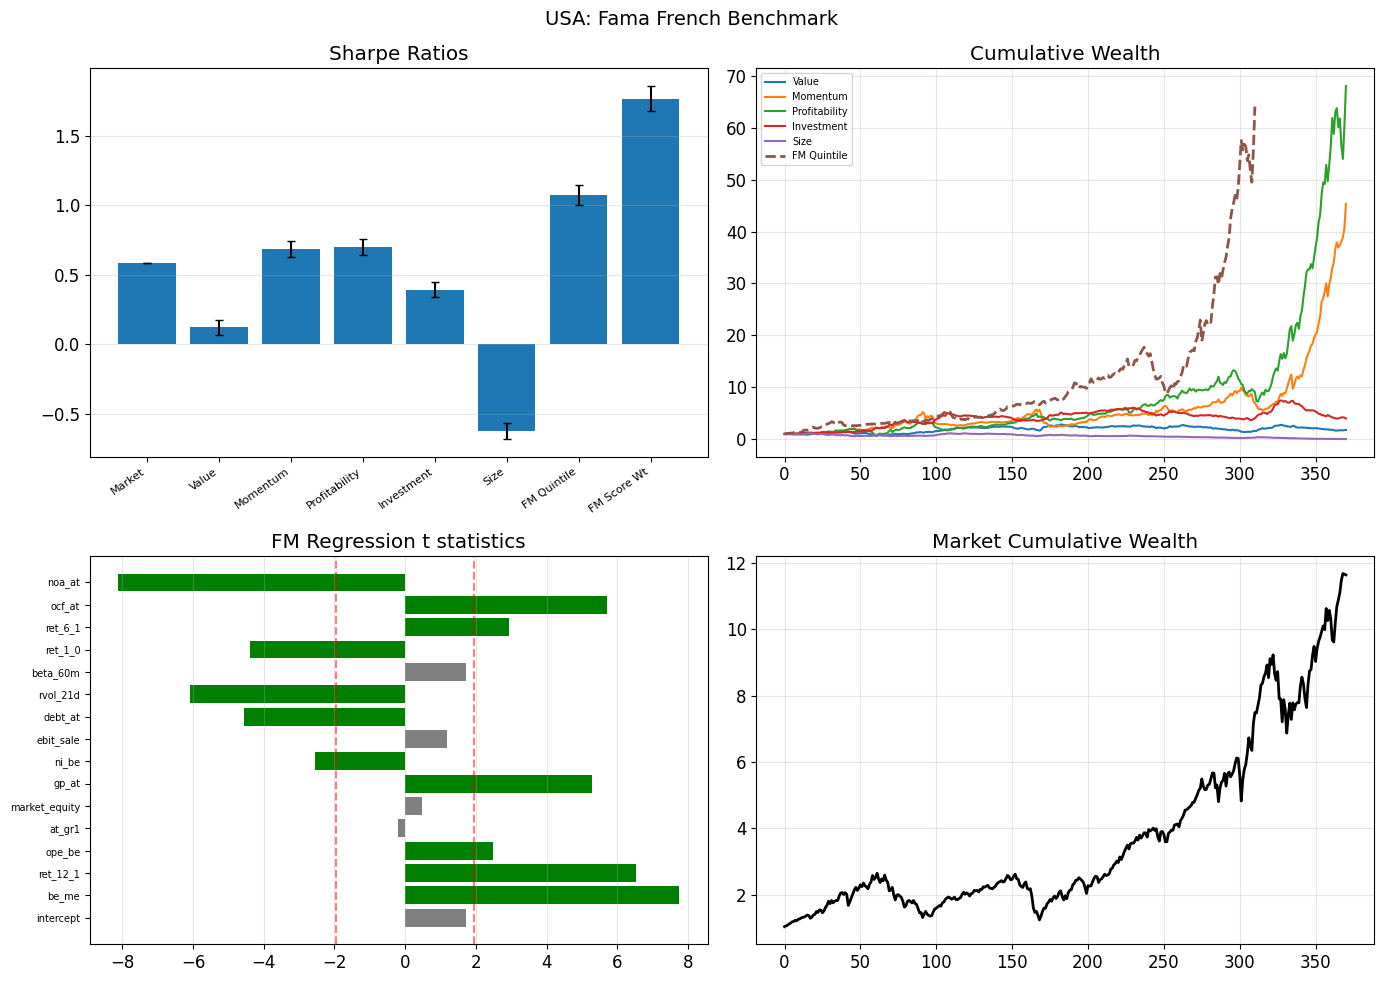

In [12]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
fig.suptitle(f'{country}: Fama French Benchmark', fontsize = 14)

# Sharpe comparison
all_names = ['Market']
all_sharpes = [mkt_sharpe]
all_ses = [0]
for fname in ['value', 'momentum', 'profitability', 'investment', 'size']:
	if fname in factor_results:
		all_names.append(fname.title())
		all_sharpes.append(factor_results[fname]['metrics']['sharpe'])
		all_ses.append(factor_results[fname]['metrics']['se_sharpe'])
all_names.extend(['FM Quintile', 'FM Score Wt'])
all_sharpes.extend([fm_q_m.get('sharpe', 0), fm_sw_m.get('sharpe', 0)])
all_ses.extend([fm_q_m.get('se_sharpe', 0), fm_sw_m.get('se_sharpe', 0)])
x = np.arange(len(all_names))
axes[0, 0].bar(x, all_sharpes, yerr = all_ses, capsize = 3)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(all_names, rotation = 35, ha = 'right', fontsize = 8)
axes[0, 0].set_title('Sharpe Ratios')
axes[0, 0].grid(axis = 'y', alpha = 0.3)

# Cumulative wealth: factors
for fname in ['value', 'momentum', 'profitability', 'investment', 'size']:
	if fname in factor_results:
		axes[0, 1].plot(np.cumprod(1 + factor_results[fname]['returns']), label = fname.title())
axes[0, 1].plot(np.cumprod(1 + fm_q_rets), label = 'FM Quintile', linewidth = 2, linestyle = '--')
axes[0, 1].set_title('Cumulative Wealth')
axes[0, 1].legend(fontsize = 7)
axes[0, 1].grid(alpha = 0.3)

# FM regression t-stats
fm_names = ['intercept'] + fm_available
x2 = np.arange(len(fm_names))
colors = ['green' if abs(fm_tstat[i]) > 1.96 else 'gray' for i in range(len(fm_names))]
axes[1, 0].barh(x2, fm_tstat, color = colors)
axes[1, 0].axvline(1.96, color = 'red', linestyle = '--', alpha = 0.5)
axes[1, 0].axvline(-1.96, color = 'red', linestyle = '--', alpha = 0.5)
axes[1, 0].set_yticks(x2)
axes[1, 0].set_yticklabels(fm_names, fontsize = 7)
axes[1, 0].set_title('FM Regression t statistics')
axes[1, 0].grid(axis = 'x', alpha = 0.3)

# Market cumulative
axes[1, 1].plot(np.cumprod(1 + market_rets), color = 'black', linewidth = 2)
axes[1, 1].set_title('Market Cumulative Wealth')
axes[1, 1].grid(alpha = 0.3)

plt.tight_layout()
plt.savefig(results_dir / f'{country}_ff_benchmark.png', dpi = 150, bbox_inches = 'tight')
plt.show()